<a href="https://colab.research.google.com/github/emmanuelduodumullen/Project-Risk-Exposure-Analysis/blob/main/Risk_Exposure_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **<h1>An Evaluation of Data Driven Models for Project Risk Exposure Analysis</h1>**

# **Import Libraries**


In [ ]:
import kagglehub
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)


# **Download Dataset**

In [ ]:
# Download dataset
path = kagglehub.dataset_download("ka66ledata/project-management-risk-raw")

print("Dataset downloaded to:", path)

100%|██████████| 263k/263k [00:00<00:00, 23.2MB/s]

Extracting files...
Dataset downloaded to: /root/.cache/kagglehub/datasets/ka66ledata/project-management-risk-raw/versions/1


In [ ]:
# List files in the directory to confirm file name
files = os.listdir(path)
print(files)

['project_risk_raw_dataset.csv']


In [ ]:
file_path = os.path.join(path, files[0])

df = pd.read_csv(file_path)
display(df.head())

,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,...,Extreme,Strategic,Formal,Basic,Hybrid,Basic,12,6,1.1,High
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,...,Moderate,Occasional,Basic,NaN,Partially Colocated,Basic,9,6,1.0,High


# **Data Inspection**

In [ ]:
# 1. Dataset structure and data types
print(df.info())

# 2. Descriptive statistics (numerical features)
display(df.describe())

# 3. Descriptive statistics (including categorical features)
print(df.describe(include='all'))

# 4. Check for duplicate rows
total_duplicates = df.duplicated().sum()
print(f"Total duplicates: {total_duplicates}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 51 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Project_ID                       4000 non-null   object 
 1   Project_Type                     4000 non-null   object 
 2   Team_Size                        4000 non-null   int64  
 3   Project_Budget_USD               4000 non-null   float64
 4   Estimated_Timeline_Months        4000 non-null   int64  
 5   Complexity_Score                 4000 non-null   float64
 6   Stakeholder_Count                4000 non-null   int64  
 7   Methodology_Used                 4000 non-null   object 
 8   Team_Experience_Level            4000 non-null   object 
 9   Past_Similar_Projects            4000 non-null   int64  
 10  External_Dependencies_Count      4000 non-null   int64  
 11  Change_Request_Frequency         4000 non-null   float64
 12  Project_Phase       

,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Past_Similar_Projects,External_Dependencies_Count,Change_Request_Frequency,Team_Turnover_Rate,Vendor_Reliability_Score,...,Market_Volatility,Integration_Complexity,Resource_Availability,Organizational_Change_Frequency,Cross_Functional_Dependencies,Previous_Delivery_Success_Rate,Technical_Debt_Level,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor
count,4000.000000,4.000000e+03,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000
mean,15.388250,1.143032e+06,17.147750,6.192525,11.130500,1.973750,3.127750,1.638080,0.292725,0.712087,...,0.49716,5.573585,0.651695,1.212215,3.549250,0.750437,0.17544,6.492500,4.074500,1.011325
std,9.220969,5.908781e+05,6.926609,2.212538,4.425875,1.750093,1.609216,1.170451,0.166546,0.163418,...,0.28702,2.606654,0.201163,0.969191,2.320004,0.143712,0.29682,3.476416,2.883926,0.031694
min,2.000000,1.593555e+05,2.000000,1.620000,2.000000,0.000000,0.000000,0.010000,0.000000,0.090000,...,0.00000,1.000000,0.300000,0.000000,0.000000,0.150000,0.00000,1.000000,1.000000,1.000000
25%,9.000000,6.925329e+05,12.000000,4.460000,8.000000,1.000000,2.000000,0.760000,0.160000,0.600000,...,0.25000,3.317500,0.480000,0.500000,2.000000,0.660000,0.00000,4.000000,2.000000,1.000000
50%,13.000000,1.007472e+06,17.000000,6.015000,10.000000,2.000000,3.000000,1.370000,0.270000,0.730000,...,0.50000,5.600000,0.650000,0.960000,4.000000,0.770000,0.00000,7.000000,3.000000,1.000000
75%,20.000000,1.475870e+06,22.000000,7.862500,14.000000,3.000000,4.000000,2.230000,0.400000,0.840000,...,0.74000,7.860000,0.820000,1.660000,6.000000,0.860000,0.28000,10.000000,6.000000,1.000000
max,50.000000,3.768354e+06,36.000000,10.000000,29.000000,10.000000,7.000000,8.840000,0.850000,1.000000,...,1.00000,10.000000,1.000000,8.230000,7.000000,0.990000,1.00000,12.000000,17.000000,1.100000


       Project_ID Project_Type    Team_Size  Project_Budget_USD  \
count        4000         4000  4000.000000        4.000000e+03   
unique       4000            6          NaN                 NaN   
top     PROJ_3984           IT          NaN                 NaN   
freq            1         1381          NaN                 NaN   
mean          NaN          NaN    15.388250        1.143032e+06   
std           NaN          NaN     9.220969        5.908781e+05   
min           NaN          NaN     2.000000        1.593555e+05   
25%           NaN          NaN     9.000000        6.925329e+05   
50%           NaN          NaN    13.000000        1.007472e+06   
75%           NaN          NaN    20.000000        1.475870e+06   
max           NaN          NaN    50.000000        3.768354e+06   

        Estimated_Timeline_Months  Complexity_Score  Stakeholder_Count  \
count                 4000.000000       4000.000000        4000.000000   
unique                        NaN              

**Findings**

<small>The dataset contains 4000 rows and 51 columns, which is sufficient for building a reliable model. It includes a balanced mix of numerical (25) and categorical (26) variables, allowing the model to capture different dimensions of project risk. No duplicate records were found, indicating good data integrity. However, missing values are present in three columns: Tech_Environment_Stability, Change_Control_Maturity, and Risk_Management_Maturity. The missing values in Tech_Environment_Stability are significantly high (over 60%), making the column unreliable. Additionally, the target variable (Risk_Level) shows some class imbalance, with “Medium” being the most frequent class, and one feature (Seasonal_Risk_Factor) shows very low variation, which may limit its predictive usefulness.</small>

**Cleaning Actions Needed**

<small>Missing value handling is required for Change_Control_Maturity and Risk_Management_Maturity using appropriate imputation methods. The Tech_Environment_Stability column will be dropped due to excessive missing data. The Project_ID column is an identifier and will be removed before modelling. Categorical variables will require encoding, and further checks will be performed to confirm consistency in category values.</small>

**Unique Value Check**

In [ ]:
# Check unique values (to detect casing / inconsistencies)
for col in df.select_dtypes(include='object').columns:
    print(f"\n{col}:")
    print(df[col].unique())


Project_ID:
['PROJ_0001' 'PROJ_0002' 'PROJ_0003' ... 'PROJ_3998' 'PROJ_3999'
 'PROJ_4000']

Project_Type:
['Construction' 'Manufacturing' 'IT' 'R&D' 'Healthcare' 'Marketing']

Methodology_Used:
['Waterfall' 'Kanban' 'Agile' 'Scrum' 'Hybrid']

Team_Experience_Level:
['Senior' 'Mixed' 'Junior' 'Expert']

Project_Phase:
['Planning' 'Execution' 'Initiation' 'Closure' 'Monitoring']

Requirement_Stability:
['Moderate' 'Stable' 'Volatile']

Regulatory_Compliance_Level:
['Medium' 'High' 'Low' 'Critical']

Technology_Familiarity:
['Expert' 'Familiar' 'New']

Stakeholder_Engagement_Level:
['Medium' 'Excellent' 'Low' 'Poor' 'High']

Executive_Sponsorship:
['Moderate' 'Weak' 'Strong']

Funding_Source:
['Government' 'External' 'Internal' 'Mixed']

Priority_Level:
['Medium' 'Low' 'High' 'Critical']

Project_Manager_Experience:
['Mid-level PM' 'Certified PM' 'Senior PM' 'Junior PM']

Org_Process_Maturity:
['Managed' 'Optimizing' 'Ad-hoc' 'Defined']

Data_Security_Requirements:
['Medium' 'Low' 'Stric

**Findings**

<small>The categorical variables are well-defined and consistent, with no visible issues such as mixed casing, duplicate labels, or unexpected values. Each feature contains a controlled number of meaningful categories, which is suitable for encoding and modelling. However, the Tech_Environment_Stability column includes missing values alongside valid categories, reinforcing the earlier decision to drop it due to high missingness.</small>

**Cleaning Actions**

<small>No action needed, for this inspection</small>

**Outlier Low Variance and class inbalance Inspection**

In [ ]:
# 1. Class distribution (Target variable)
print(df['Risk_Level'].value_counts())
print(df['Risk_Level'].value_counts(normalize=True) * 100)


# 2. Low variance check
print("\nSeasonal_Risk_Factor stats:")
print(df['Seasonal_Risk_Factor'].describe())
print("Variance:", df['Seasonal_Risk_Factor'].var())


# 3. Outlier detection using IQR
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = len(outliers)

# Show columns with outliers
for col, count in outlier_summary.items():
    if count > 0:
        print(f"{col}: {count} outliers")

Risk_Level
Medium      1396
High        1036
Low          806
Critical     762
Name: count, dtype: int64
Risk_Level
Medium      34.90
High        25.90
Low         20.15
Critical    19.05
Name: proportion, dtype: float64

Seasonal_Risk_Factor stats:
count    4000.000000
mean        1.011325
std         0.031694
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.100000
Name: Seasonal_Risk_Factor, dtype: float64
Variance: 0.0010044954988747488
Team_Size: 152 outliers
Project_Budget_USD: 72 outliers
Stakeholder_Count: 38 outliers
Past_Similar_Projects: 64 outliers
Change_Request_Frequency: 117 outliers
Team_Turnover_Rate: 16 outliers
Vendor_Reliability_Score: 16 outliers
Historical_Risk_Incidents: 263 outliers
Communication_Frequency: 113 outliers
Schedule_Pressure: 340 outliers
Organizational_Change_Frequency: 158 outliers
Previous_Delivery_Success_Rate: 47 outliers
Technical_Debt_Level: 427 outliers
Current_Phase_Duration_Months: 42 outlier

**Findings**

<small>The target variable (Risk_Level) shows moderate class imbalance, with “Medium” being the most frequent class (34.9%), but the distribution is still reasonably balanced across other classes. The feature Seasonal_Risk_Factor exhibits extremely low variance, with most values concentrated at 1.0, indicating limited predictive usefulness. Outlier analysis revealed the presence of extreme values across several numerical features such as Project_Budget_USD, Technical_Debt_Level, and Schedule_Pressure. However, these values are considered valid representations of real-world project conditions rather than data errors.</small>

**Cleaning Action**

<small>The Seasonal_Risk_Factor feature will be dropped due to its low variance. The class imbalance in Risk_Level will be handled during modelling using class weighting. Outliers will not be removed, as they contain important information relevant to risk prediction. Instead, appropriate preprocessing techniques such as log transformation (for skewed features) and RobustScaler will be applied to reduce their impact while preserving critical data patterns.</small>


# **Data Cleaning**

In [ ]:
# Make a copy to preserve original data
df_clean = df.copy()


# 1. Drop columns with excessive missing values
df_clean.drop(columns=['Tech_Environment_Stability'], inplace=True)


# 2. Drop non-informative identifier
df_clean.drop(columns=['Project_ID'], inplace=True)


# 3. Handle missing values (categorical → use mode)
df_clean['Change_Control_Maturity'] = df_clean['Change_Control_Maturity'].fillna(
    df_clean['Change_Control_Maturity'].mode()[0]
)

df_clean['Risk_Management_Maturity'] = df_clean['Risk_Management_Maturity'].fillna(
    df_clean['Risk_Management_Maturity'].mode()[0]
)


# 4. Drop low variance feature
df_clean.drop(columns=['Seasonal_Risk_Factor'], inplace=True)


# 5. Final check
print("Remaining missing values:\n", df_clean.isnull().sum())
print("\nDataset shape after cleaning:", df_clean.shape)

Remaining missing values:
 Project_Type                       0
Team_Size                          0
Project_Budget_USD                 0
Estimated_Timeline_Months          0
Complexity_Score                   0
Stakeholder_Count                  0
Methodology_Used                   0
Team_Experience_Level              0
Past_Similar_Projects              0
External_Dependencies_Count        0
Change_Request_Frequency           0
Project_Phase                      0
Requirement_Stability              0
Team_Turnover_Rate                 0
Vendor_Reliability_Score           0
Historical_Risk_Incidents          0
Communication_Frequency            0
Regulatory_Compliance_Level        0
Technology_Familiarity             0
Geographical_Distribution          0
Stakeholder_Engagement_Level       0
Schedule_Pressure                  0
Budget_Utilization_Rate            0
Executive_Sponsorship              0
Funding_Source                     0
Market_Volatility                  0
Integration

<small>After cleaning, all missing values were successfully handled, irrelevant features were removed, and the dataset was reduced to 48 meaningful variables. The dataset is now complete and suitable for further analysis and modelling.</small>

# **Exploratory Data Analysis**


1. Target Variable **Analysis**

Risk_Level
Medium      1396
High        1036
Low          806
Critical     762
Name: count, dtype: int64
Risk_Level
Medium      34.90
High        25.90
Low         20.15
Critical    19.05
Name: proportion, dtype: float64


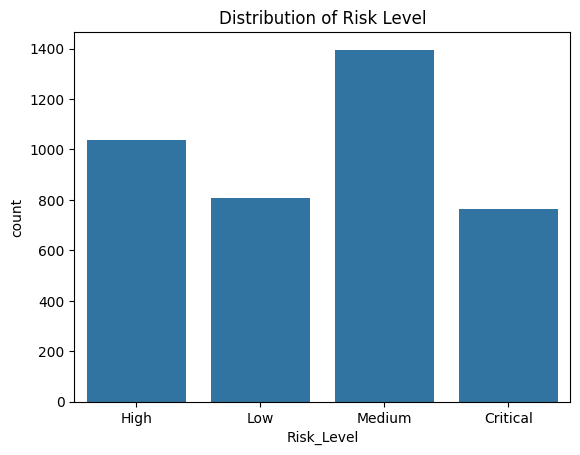

In [ ]:
# Count distribution
print(df_clean['Risk_Level'].value_counts())

# Percentage distribution
print(df_clean['Risk_Level'].value_counts(normalize=True) * 100)

sns.countplot(x='Risk_Level', data=df_clean)
plt.title("Distribution of Risk Level")
plt.show()

**Findings**

<small>The distribution of the target variable (Risk_Level) shows that “Medium” risk projects are the most frequent, accounting for 34.9% of the dataset. The remaining classes—“High” (25.9%), “Low” (20.15%), and “Critical” (19.05%)—are relatively well distributed. This indicates a moderate class imbalance, but not severe enough to significantly bias the model. Overall, the distribution is sufficiently balanced to support reliable classification, although class weighting may be applied during modelling to ensure fair learning across all classes.</small>

**2. Univariate Analysis**

<ul>
<li> Numerical Features</li>
</ul>


<p>Things to look out for</p>
<ol>
<li><small>Right skew → common in budget, frequency variables</small></li>
<li><small>Extreme values → confirm earlier outlier findings</small></li>
<li><small>Spread differences → some variables may dominate the model</small></li>
</ol>


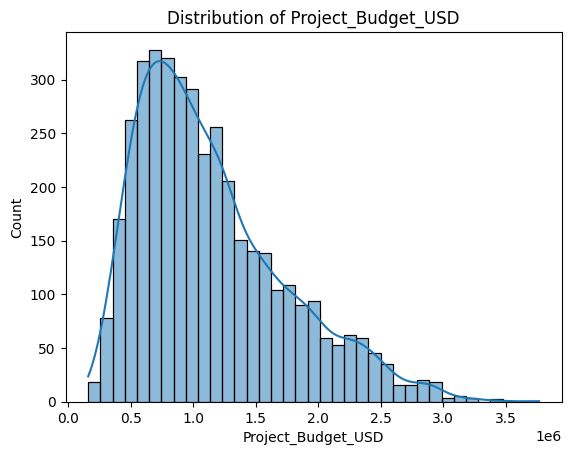

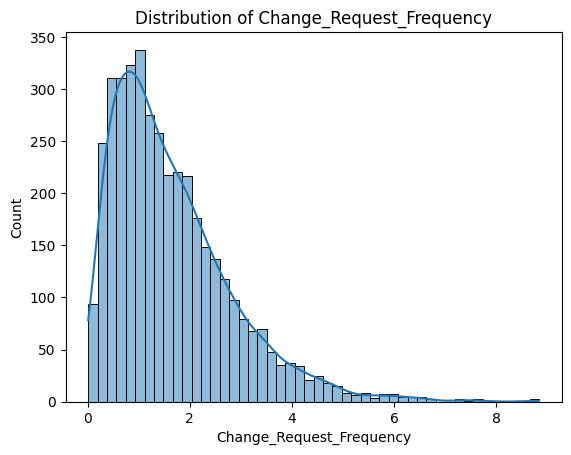

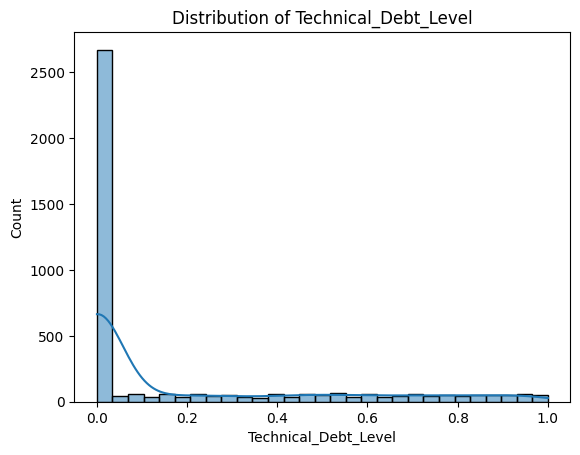

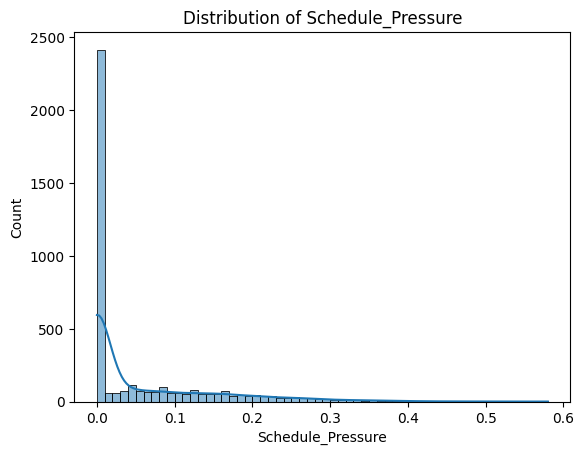

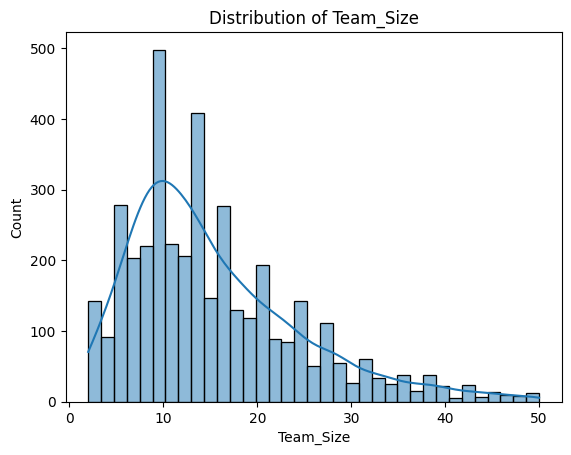

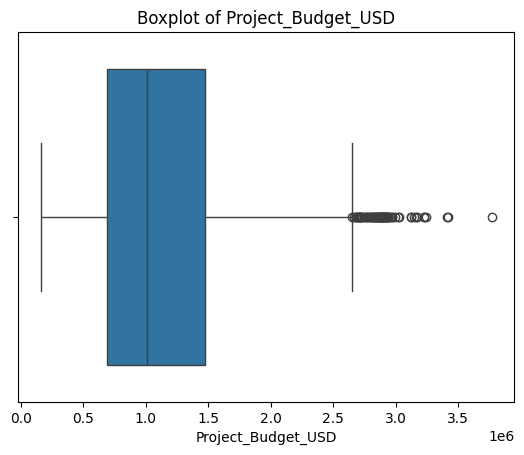

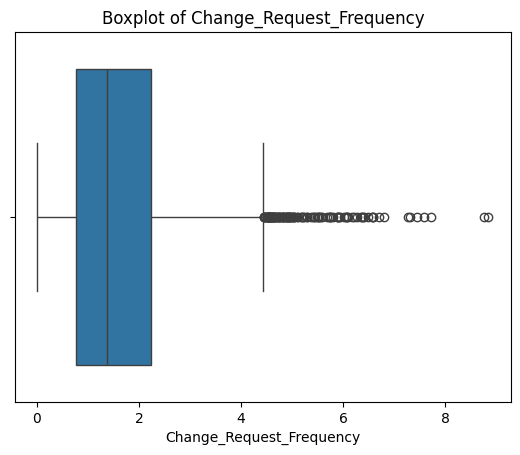

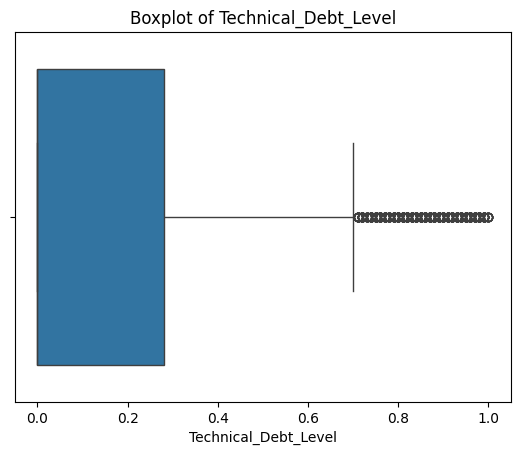

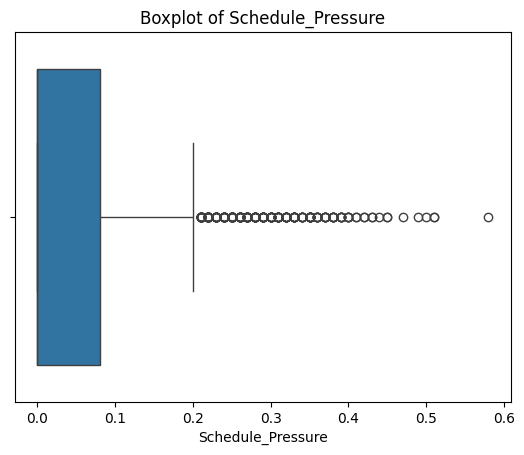

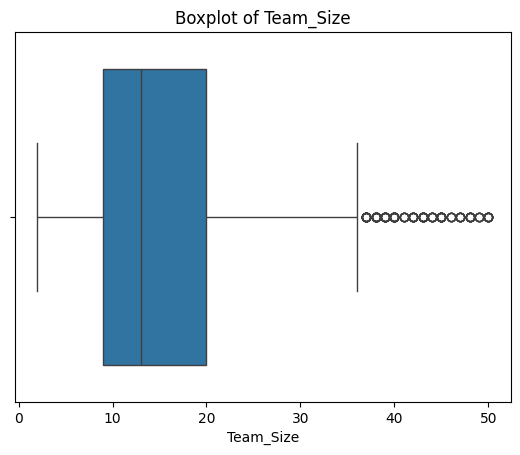

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = [
    'Project_Budget_USD',
    'Change_Request_Frequency',
    'Technical_Debt_Level',
    'Schedule_Pressure',
    'Team_Size'
]

# Histograms
for col in num_cols:
    plt.figure()
    sns.histplot(df_clean[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


# Boxplots
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

**Findings**

<small>The numerical features show right-skewed distributions, with most values concentrated at lower levels and a few extreme high values. Project_Budget_USD is moderately skewed, while Change_Request_Frequency, Technical_Debt_Level, Schedule_Pressure, and Team_Size show stronger skewness.

Variables such as Technical_Debt_Level and Schedule_Pressure have many values near zero, with a few high extremes. Boxplots confirm the presence of outliers across all variables; however, these represent real project risk conditions rather than errors. Overall, the data is non-normal and contains meaningful extreme values important for modelling. </small>

**2. Univariate Analysis**

<ul>
<li> Categorical Features</li>
</ul>

<p>Things to look out for</p>
<ol>
<li><small>Identify dominant categories</small></li>
<li><small>Understand dataset composition</small></li>
</ol>

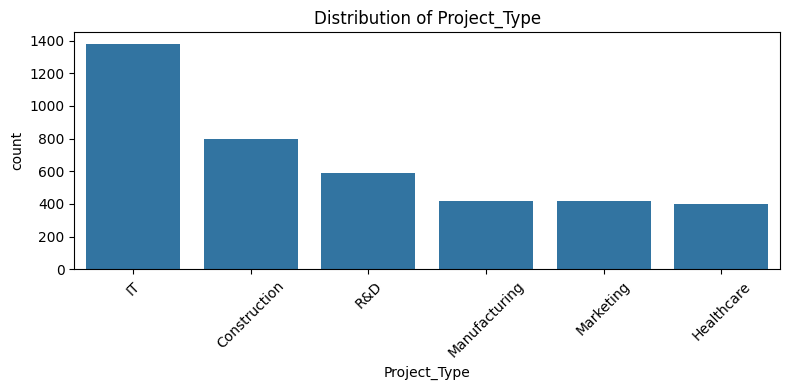

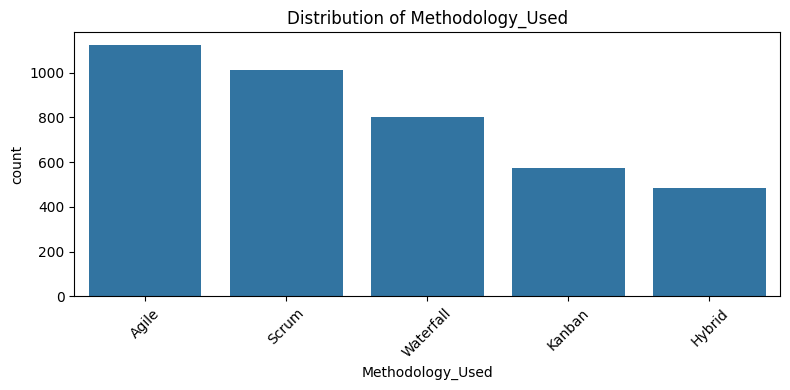

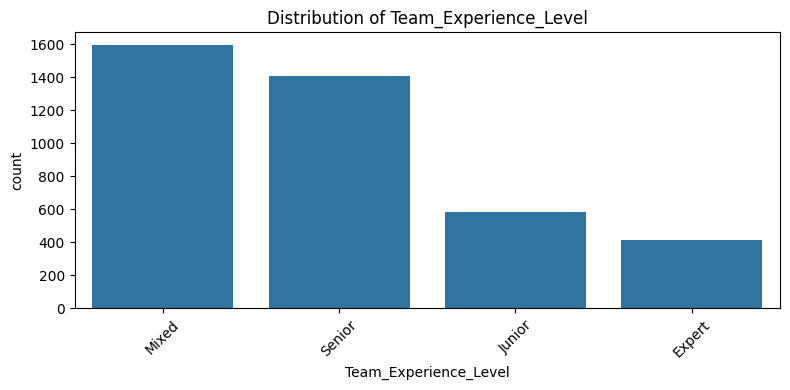

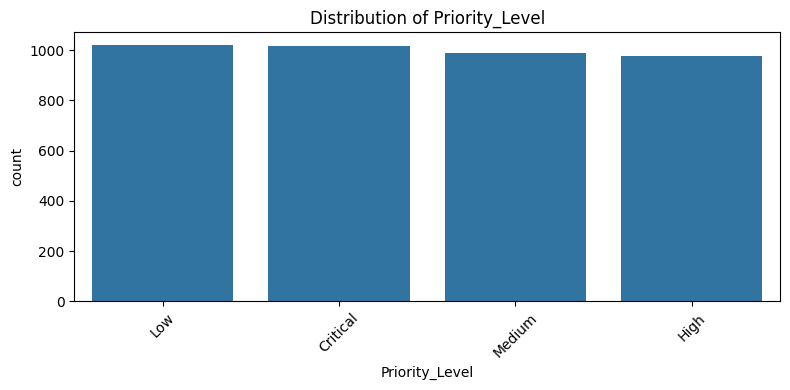

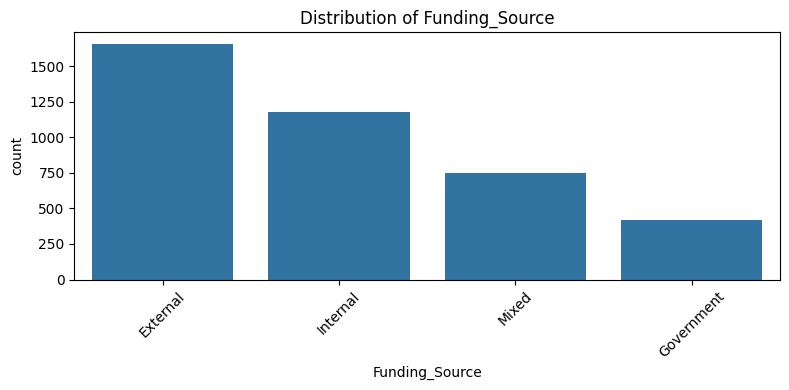

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_cols = [
    'Project_Type',
    'Methodology_Used',
    'Team_Experience_Level',
    'Priority_Level',
    'Funding_Source'
]

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df_clean, order=df_clean[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

**Findings**

<small> The categorical analysis shows that the dataset is reasonably well distributed across most variables, with some dominant categories. Project_Type is led by IT projects (34.5%), followed by Construction and R&D, indicating a stronger representation of technology-related projects. Methodology_Used is dominated by Agile (28.1%) and Scrum (25.4%), suggesting modern development approaches are more common.</small>

<small>Team_Experience_Level is largely composed of Mixed (39.8%) and Senior (35.2%) teams, with fewer Junior and Expert-only teams. Priority_Level is evenly distributed across all categories, indicating no bias in project urgency. However, Funding_Source is skewed towards External funding (41.4%), followed by Internal funding.</small>

<small>The distributions show a balanced but slightly skewed composition, which is suitable for modelling while still reflecting real-world project environments.
</small>

**3. Bivariate Analysis (Feature vs Target)**

<p>Things to look out for</p>

<ol>
<p>Categorical:</p>
<li><small>Which categories have more High / Critical risk</small></li>
</ol>
<ol><p>Numerical:</p>
<li><small>Do higher values → higher risk?</small></li>
</ol>


===== Project_Type vs Risk_Level (Percentage) =====
Risk_Level     Critical   High    Low  Medium
Project_Type                                 
Construction      19.20  28.36  20.45   31.99
Healthcare        10.30  20.60  28.39   40.70
IT                17.23  22.66  22.09   38.02
Manufacturing     13.64  23.68  24.88   37.80
Marketing         14.83  28.71  19.86   36.60
R&D               35.88  33.33   6.46   24.32


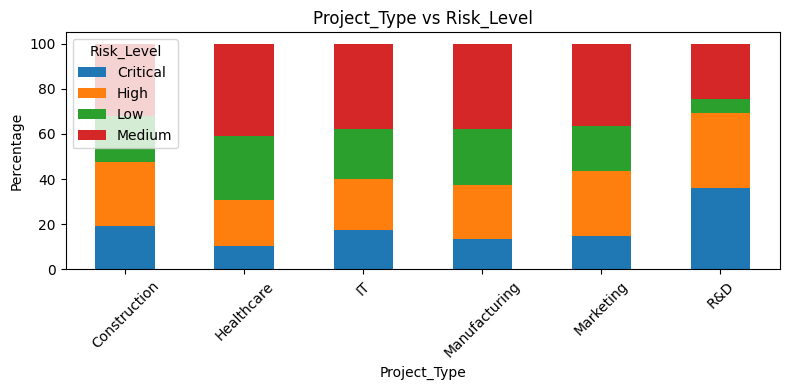


===== Methodology_Used vs Risk_Level (Percentage) =====
Risk_Level        Critical   High    Low  Medium
Methodology_Used                                
Agile                22.95  24.20  18.15   34.70
Hybrid               14.81  27.37  25.10   32.72
Kanban               13.22  24.87  23.30   38.61
Scrum                19.92  25.94  18.93   35.21
Waterfall            19.23  28.09  19.23   33.46


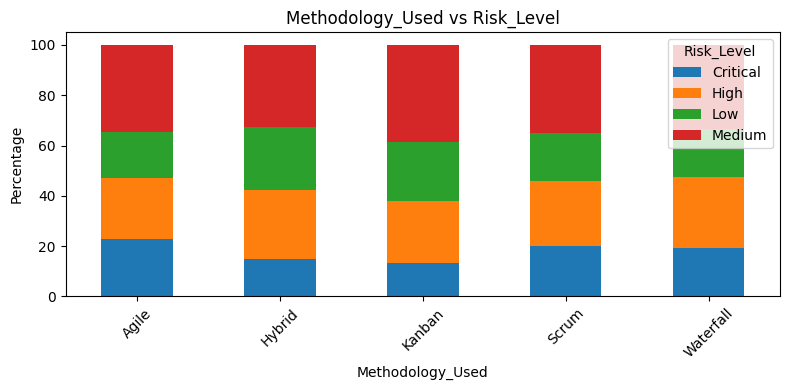


===== Team_Experience_Level vs Risk_Level (Percentage) =====
Risk_Level             Critical   High    Low  Medium
Team_Experience_Level                                
Expert                     3.37   8.43  55.90   32.29
Junior                    33.85  27.86  11.28   27.01
Mixed                     21.47  30.57  11.74   36.22
Senior                    14.78  24.95  22.81   37.46


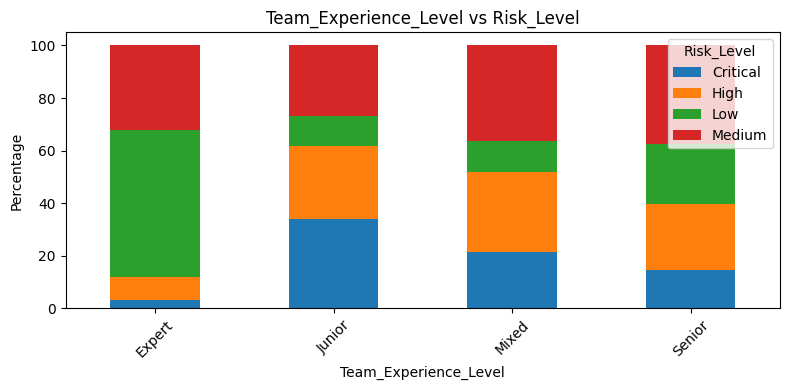


===== Priority_Level vs Risk_Level (Percentage) =====
Risk_Level      Critical   High    Low  Medium
Priority_Level                                
Critical           18.11  27.46  20.47   33.96
High               19.08  25.54  20.31   35.08
Low                19.31  26.86  20.88   32.94
Medium             19.72  23.66  18.91   37.71


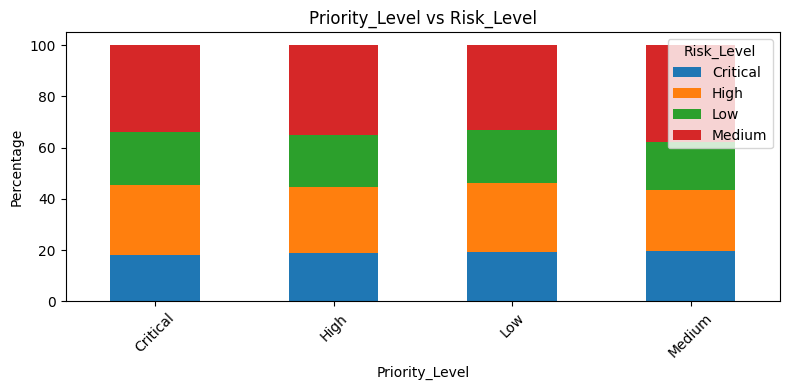

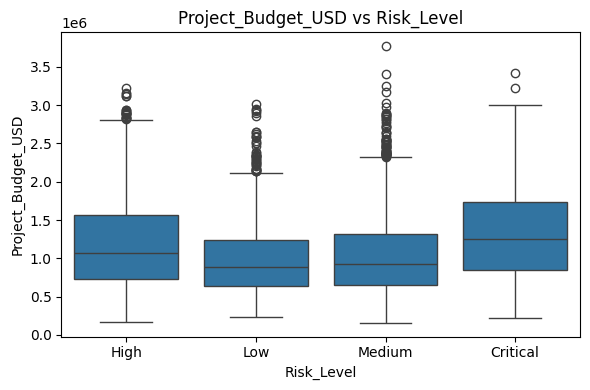

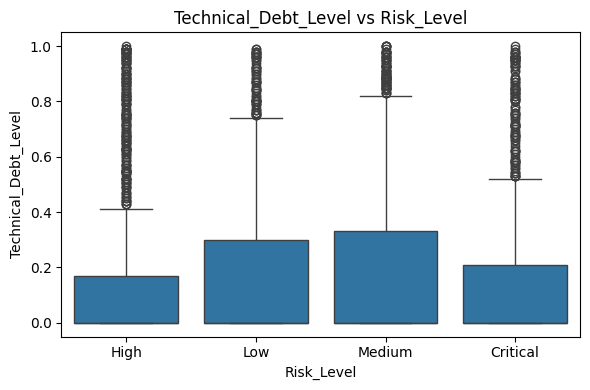

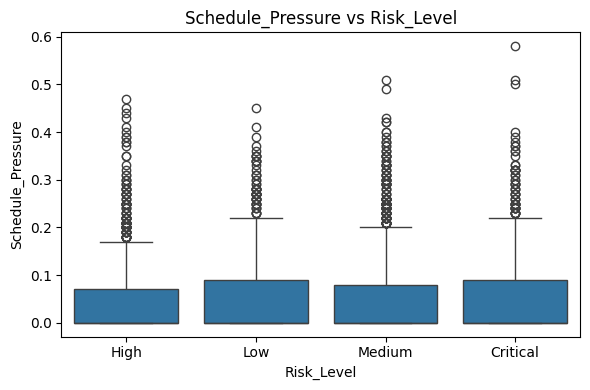

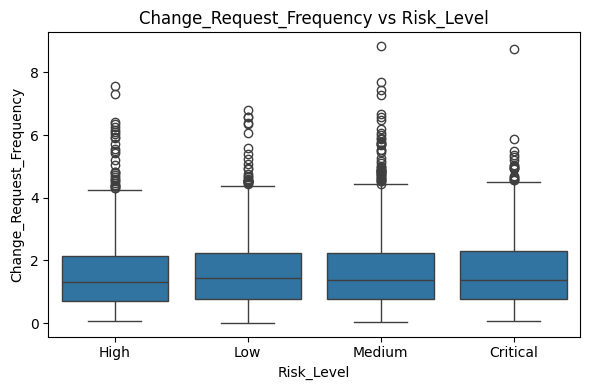


===== Numerical Summary by Risk_Level =====


,Project_Budget_USD,Technical_Debt_Level,Schedule_Pressure,Change_Request_Frequency
Risk_Level,,,,
Critical,1.325672e+06,0.166024,0.057218,1.658202
High,1.204937e+06,0.164923,0.047712,1.575183
Low,1.014943e+06,0.179268,0.054764,1.672159
Medium,1.071350e+06,0.186175,0.054556,1.654097


In [ ]:
# -------------------------------
# CATEGORICAL vs TARGET
# -------------------------------
cat_cols = [
    'Project_Type',
    'Methodology_Used',
    'Team_Experience_Level',
    'Priority_Level'
]

for col in cat_cols:
    print(f"\n===== {col} vs Risk_Level (Percentage) =====")

    # Percentage table
    ct = pd.crosstab(df_clean[col], df_clean['Risk_Level'], normalize='index') * 100
    print(ct.round(2))

    # Stacked bar plot
    ct.plot(kind='bar', stacked=True, figsize=(8,4))
    plt.title(f"{col} vs Risk_Level")
    plt.ylabel("Percentage")
    plt.xticks(rotation=45)
    plt.legend(title='Risk_Level')
    plt.tight_layout()
    plt.show()


# -------------------------------
# NUMERICAL vs TARGET
# -------------------------------
num_cols = [
    'Project_Budget_USD',
    'Technical_Debt_Level',
    'Schedule_Pressure',
    'Change_Request_Frequency'
]

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Risk_Level', y=col, data=df_clean)
    plt.title(f"{col} vs Risk_Level")
    plt.tight_layout()
    plt.show()


# -------------------------------
# OPTIONAL: Numerical Summary by Target (for copy-paste)
# -------------------------------
print("\n===== Numerical Summary by Risk_Level =====")
display(df_clean.groupby('Risk_Level')[num_cols].mean())

**Findings**

<small>The bivariate analysis reveals that Team_Experience_Level is a strong predictor of project risk, as projects with Junior teams show significantly higher Critical risk, while Expert teams are mostly associated with Low risk. Project_Type also influences risk, with R&D projects exhibiting the highest proportion of Critical and High risk levels, whereas Healthcare projects tend to have lower risk. In contrast, Methodology_Used and Priority_Level show relatively uniform distributions across risk levels, indicating limited influence on project risk. From the numerical analysis, Project_Budget_USD shows a moderate relationship with risk, as higher budgets are associated with higher risk levels, while Technical_Debt_Level, Schedule_Pressure, and Change_Request_Frequency display minimal variation across risk categories, suggesting weaker predictive impact.</small>

**4. Correlation Analysis**

<p>Things to look for</p>
<ol>
<li><small>Strong relationships between features</small></li>
<li><small>Features strongly related to risk drivers</small></li>
</ol>

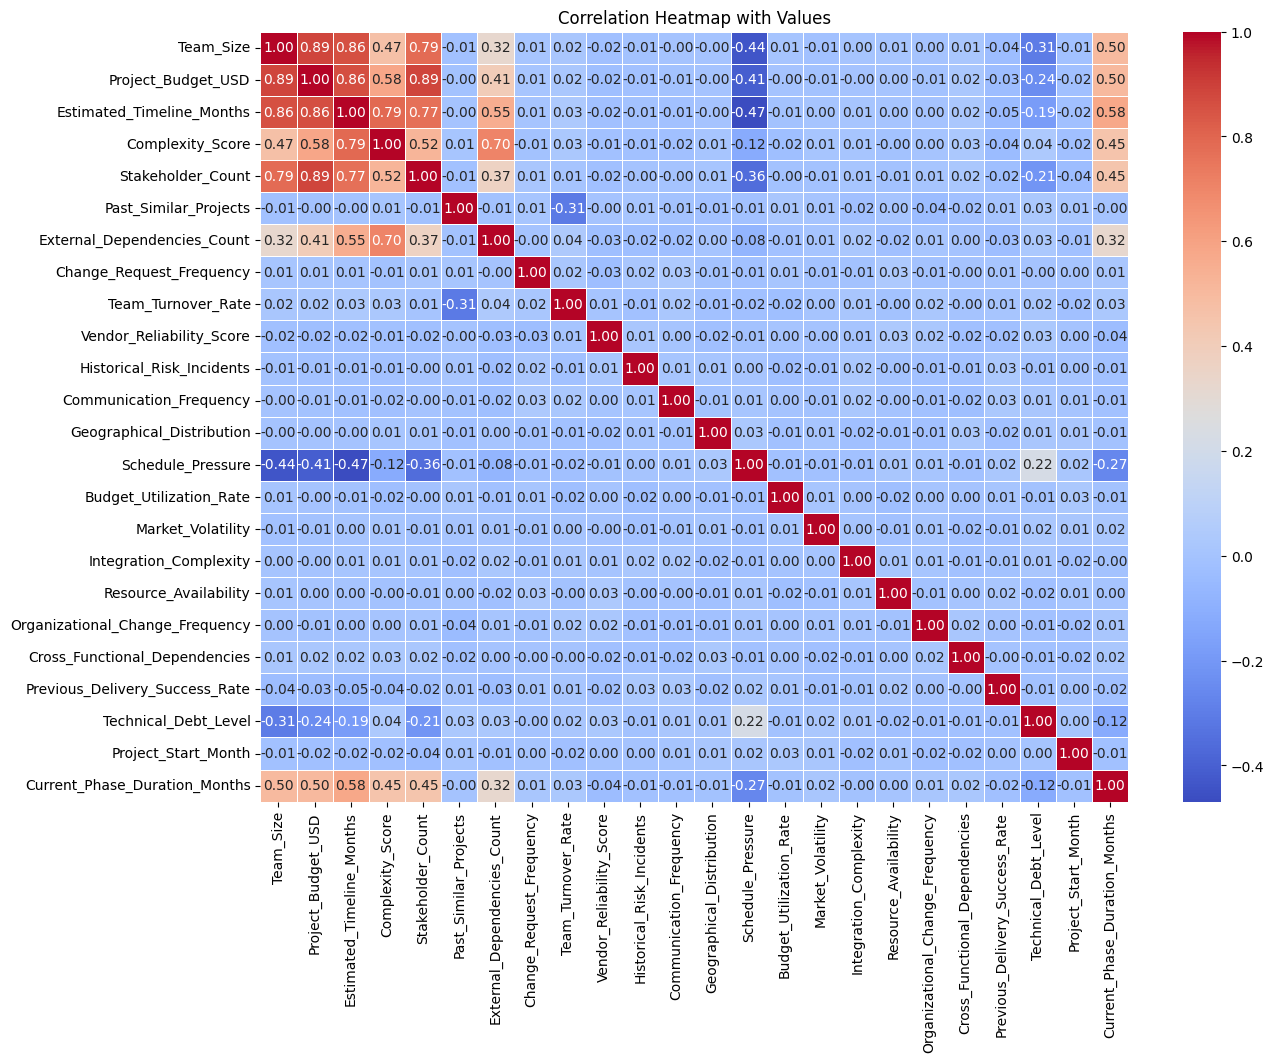

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,10))
sns.heatmap(
    df_clean.corr(numeric_only=True),
    cmap='coolwarm',
    annot=True,          # 👈 shows numbers
    fmt=".2f",           # 👈 2 decimal places
    linewidths=0.5
)
plt.title("Correlation Heatmap with Values")
plt.show()

**Findings**

<small>The correlation analysis reveals several strong positive relationships among project size-related variables. Notably, Project_Budget_USD, Team_Size, Estimated_Timeline_Months, and Stakeholder_Count are highly correlated (values above 0.75), indicating potential multicollinearity, as these variables tend to increase together. This suggests they capture similar underlying project scale characteristics.</small>

<small>Additionally, Complexity_Score and External_Dependencies_Count show moderate to strong correlations with these variables, reinforcing their association with larger and more complex projects. On the other hand, most other features exhibit weak correlations (values close to zero), indicating they provide unique information and are less redundant.</small>

<small>A moderate negative relationship is observed between Schedule_Pressure and key project size variables, suggesting that larger projects may experience relatively lower schedule pressure. Overall, while some multicollinearity exists among size-related features, the majority of variables are weakly correlated, which is beneficial for model performance and reduces the risk of redundancy.</small>


Project_Type + Team_Experience_Level vs Risk_Level
Risk_Level                           Critical  High   Low  Medium
Project_Type  Team_Experience_Level                              
Construction  Expert                     0.03  0.08  0.59    0.30
              Junior                     0.35  0.32  0.09    0.24
              Mixed                      0.22  0.32  0.13    0.34
              Senior                     0.13  0.28  0.24    0.34
Healthcare    Expert                     0.00  0.07  0.69    0.24
              Junior                     0.18  0.29  0.15    0.38
              Mixed                      0.14  0.26  0.16    0.43
              Senior                     0.06  0.16  0.33    0.45
IT            Expert                     0.05  0.07  0.57    0.31
              Junior                     0.37  0.26  0.13    0.24
              Mixed                      0.18  0.28  0.13    0.40
              Senior                     0.12  0.20  0.25    0.43
Manufacturing Expert    

,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Past_Similar_Projects,External_Dependencies_Count,Change_Request_Frequency,Team_Turnover_Rate,Vendor_Reliability_Score,...,Budget_Utilization_Rate,Market_Volatility,Integration_Complexity,Resource_Availability,Organizational_Change_Frequency,Cross_Functional_Dependencies,Previous_Delivery_Success_Rate,Technical_Debt_Level,Project_Start_Month,Current_Phase_Duration_Months
Risk_Level,,,,,,,,,,,,,,,,,,,,,
Critical,18.06,1325672.32,20.47,7.59,12.36,1.65,3.93,1.66,0.35,0.69,...,0.97,0.53,5.93,0.63,1.15,3.82,0.71,0.17,6.37,4.90
High,16.31,1204937.49,18.04,6.45,11.50,1.78,3.24,1.58,0.31,0.71,...,0.94,0.52,5.68,0.64,1.28,3.61,0.74,0.16,6.59,4.33
Low,13.68,1014943.12,14.86,5.25,10.25,2.48,2.63,1.67,0.23,0.72,...,0.93,0.44,5.16,0.69,1.18,3.35,0.78,0.18,6.44,3.58
Medium,14.24,1071349.79,15.99,5.78,10.70,2.00,2.90,1.65,0.29,0.72,...,0.95,0.49,5.54,0.65,1.22,3.47,0.76,0.19,6.52,3.72


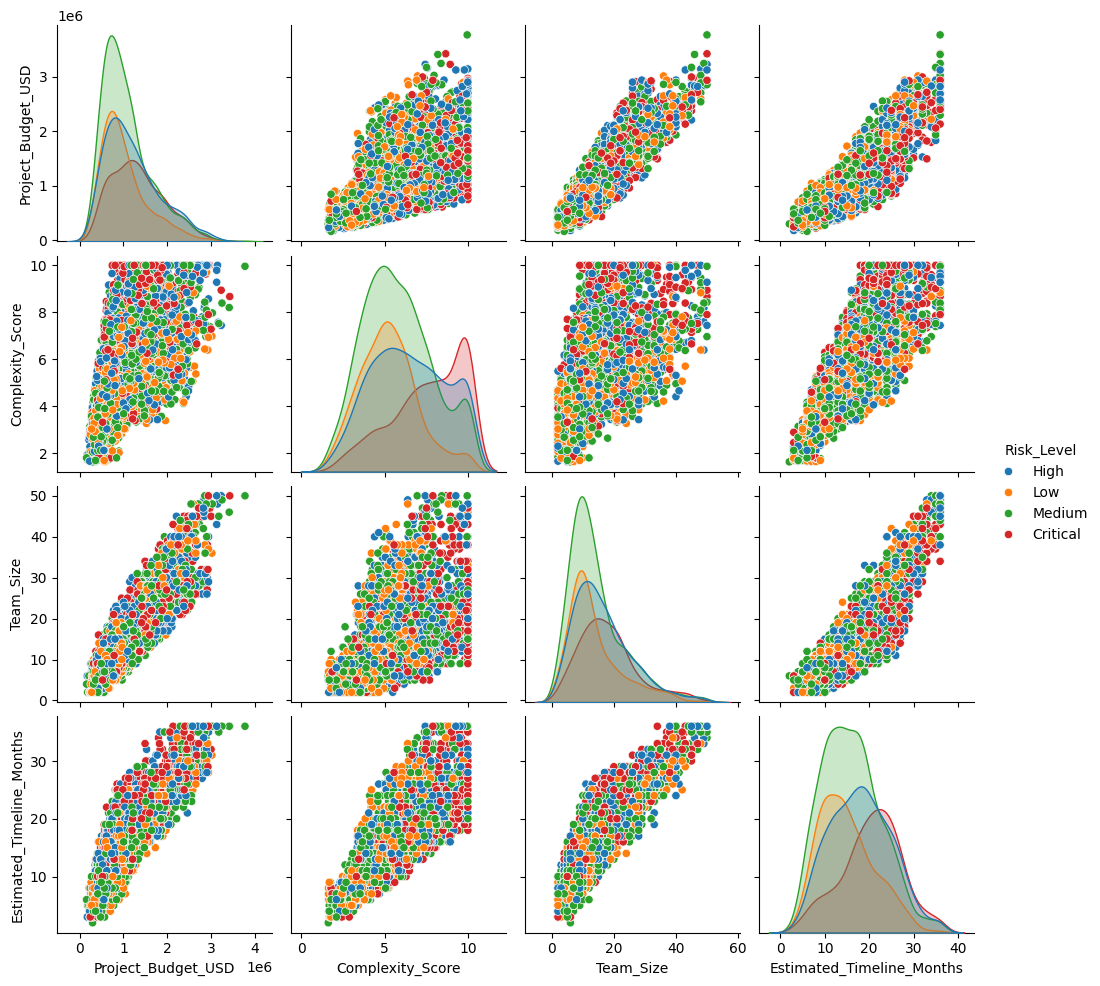

In [ ]:
print("\nProject_Type + Team_Experience_Level vs Risk_Level")
print(pd.crosstab(
    [df_clean['Project_Type'], df_clean['Team_Experience_Level']],
    df_clean['Risk_Level'],
    normalize='index'
).round(2))


print("\nPriority_Level + Team_Experience_Level vs Risk_Level")
print(pd.crosstab(
    [df_clean['Priority_Level'], df_clean['Team_Experience_Level']],
    df_clean['Risk_Level'],
    normalize='index'
).round(2))

import seaborn as sns

key_cols = [
    'Project_Budget_USD',
    'Complexity_Score',
    'Team_Size',
    'Estimated_Timeline_Months',
    'Risk_Level'
]

sns.pairplot(df_clean[key_cols], hue='Risk_Level')

df_clean.groupby('Risk_Level').mean(numeric_only=True).round(2)

**Findings**

<small>The interaction analysis shows that team experience significantly influences project risk across all conditions. Projects with Junior teams consistently exhibit higher Critical risk, especially in complex environments such as R&D, where Critical risk reaches as high as 60%. In contrast, Expert teams are strongly associated with Low risk across all project types and priority levels, indicating that experience mitigates risk regardless of other factors. Senior and Mixed teams fall between these extremes, showing moderate risk levels.</small>

<small>From the pairplot and grouped statistics, it is evident that higher-risk projects (Critical and High) are generally associated with larger team sizes, higher budgets, longer timelines, and greater complexity, confirming that project scale and complexity are key risk drivers. Conversely, low-risk projects tend to be smaller, less complex, and more stable.</small>

<small>The analysis highlights that team experience, project complexity, and project scale are the most influential factors driving risk, while other variables have a more limited or indirect impact.</small>

# **Preprocessing Pipeline**

In [ ]:
# ===============================
# PREPROCESSING PIPELINE (BINARY CLASSIFICATION)
# ===============================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# ---------------------------------
# 1. Make a working copy
# ---------------------------------
df_prep = df_clean.copy()

# ---------------------------------
# 2. Convert target to binary
# Low = 0
# Medium, High, Critical = 1
# ---------------------------------
df_prep['Risk_Level'] = df_prep['Risk_Level'].map({
    'Low': 0,
    'Medium': 1,
    'High': 1,
    'Critical': 1
})

# Check target distribution
print("Binary Target Distribution:")
print(df_prep['Risk_Level'].value_counts())
print("\nBinary Target Percentage:")
print((df_prep['Risk_Level'].value_counts(normalize=True) * 100).round(2))

# ---------------------------------
# 3. Apply log transformation to selected skewed numerical features
# ---------------------------------
log_transform_cols = [
    'Project_Budget_USD',
    'Change_Request_Frequency',
    'Schedule_Pressure',
    'Team_Size'
]

for col in log_transform_cols:
    df_prep[col] = np.log1p(df_prep[col])

# ---------------------------------
# 4. One-hot encode categorical variables
# ---------------------------------
categorical_cols = df_prep.select_dtypes(include=['object']).columns
df_prep = pd.get_dummies(df_prep, columns=categorical_cols, drop_first=True)

# ---------------------------------
# 5. Split into features and target
# ---------------------------------
X = df_prep.drop('Risk_Level', axis=1)
y = df_prep['Risk_Level']

# ---------------------------------
# 6. Train-test split
# ---------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# ---------------------------------
# 7. Scale numerical features using RobustScaler
# ---------------------------------
numerical_cols = X_train.select_dtypes(include=['int64', 'float64', 'bool']).columns

# Remove target if present by mistake
numerical_cols = [col for col in numerical_cols if col in X_train.columns]

scaler = RobustScaler()

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# ---------------------------------
# 8. Final checks
# ---------------------------------
print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTarget distribution in y_train:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nTarget distribution in y_test:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(2))

print("\nPreview of preprocessed training data:")
display(X_train.head())

Binary Target Distribution:
Risk_Level
1    3194
0     806
Name: count, dtype: int64

Binary Target Percentage:
Risk_Level
1    79.85
0    20.15
Name: proportion, dtype: float64

X_train shape: (2800, 93)
X_test shape: (1200, 93)
y_train shape: (2800,)
y_test shape: (1200,)

Target distribution in y_train:
Risk_Level
0    20.14
1    79.86
Name: proportion, dtype: float64

Target distribution in y_test:
Risk_Level
0    20.17
1    79.83
Name: proportion, dtype: float64

Preview of preprocessed training data:


,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Past_Similar_Projects,External_Dependencies_Count,Change_Request_Frequency,Team_Turnover_Rate,Vendor_Reliability_Score,...,Change_Control_Maturity_Basic,Change_Control_Maturity_Formal,Risk_Management_Maturity_Basic,Risk_Management_Maturity_Formal,Team_Colocation_Fully Remote,Team_Colocation_Hybrid,Team_Colocation_Partially Colocated,Documentation_Quality_Excellent,Documentation_Quality_Good,Documentation_Quality_Poor
2573,0.000000,0.159681,-0.3,-0.554164,-0.333333,0.0,0.5,-0.399230,0.869565,0.333333,...,1.0,-1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3247,-0.595512,-0.775051,-0.8,-0.595431,-0.833333,-0.5,-1.5,0.458760,-0.086957,-1.125000,...,0.0,0.0,-1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
65,-0.453505,-0.743714,-0.8,-0.241710,-0.166667,-0.5,-0.5,-0.346949,0.956522,-0.375000,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3667,0.000000,0.202004,0.7,0.919676,-0.166667,-0.5,0.5,0.515761,-0.695652,0.041667,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
352,1.195927,0.746329,0.7,0.120855,0.500000,0.0,0.0,0.041217,-0.043478,0.625000,...,1.0,-1.0,-1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0


**Findings**

<small>The preprocessing stage successfully transformed the dataset into a format suitable for machine learning. After encoding categorical variables, the feature space increased to 93 features, reflecting the expansion from one-hot encoding. The dataset was split into training (2800 samples) and testing (1200 samples) sets using stratified sampling, ensuring that the class distribution of the target variable (Risk_Level) remained consistent across both sets.</small>

<small>The application of log transformation reduced skewness in key numerical variables, while RobustScaler standardised the feature values, making them comparable despite the presence of outliers. The scaled values now fall within a similar range, improving model stability and performance. Overall, the dataset is well-balanced, numerically stable, and fully prepared for model training and evaluation.</small>

<small>The original four-class risk categorisation exhibited significant overlap between adjacent classes, particularly between Medium, High, and Critical risk levels. To improve model interpretability and predictive performance, the problem was reformulated as a binary classification task by grouping Medium, High, and Critical into a single High-Risk category. This approach aligns with practical decision-making scenarios where the primary concern is identifying whether a project is at risk or not.</small>

# **Model Development**

### **Model Training**

In [ ]:

log_reg = LogisticRegression(
    max_iter=5000,
    class_weight='balanced',
    random_state=42
)

param_grid = [
    {
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 5, 10, 20, 50, 100]
    },
    {
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 5, 10, 20, 50, 100]
    }
]

grid = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=10,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("Best Parameters:", grid.best_params_)

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Best Parameters: {'C': 20, 'penalty': 'l2', 'solver': 'newton-cg'}


**Findings**

<small>The Logistic Regression model was trained using GridSearchCV with 10-fold cross-validation, evaluating 40 different hyperparameter combinations, resulting in a total of 400 model fits. This approach ensured robust parameter selection and improved generalisation performance. The optimal configuration identified was a regularisation strength of C = 20, with L2 regularisation and the newton-cg solver. This indicates that a relatively lower level of regularisation was more suitable for capturing the underlying patterns in the data while maintaining model stability.</small>

Model Evaluation


===== FURTHER TUNED LOGISTIC REGRESSION =====
Accuracy  : 0.8950
Precision : 0.9152
F1-Score  : 0.9003
ROC-AUC   : 0.9666

===== CLASSIFICATION REPORT (TEXT) =====

              precision    recall  f1-score   support

    Low Risk       0.68      0.91      0.78       242
   High Risk       0.97      0.89      0.93       958

    accuracy                           0.90      1200
   macro avg       0.83      0.90      0.85      1200
weighted avg       0.92      0.90      0.90      1200


===== CONFUSION MATRIX =====



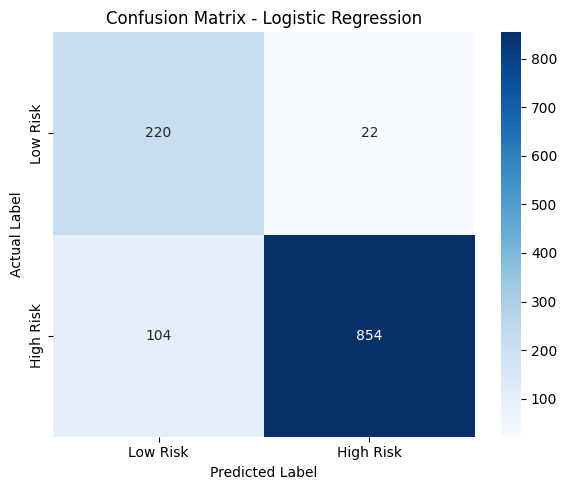


===== ROC CURVE =====



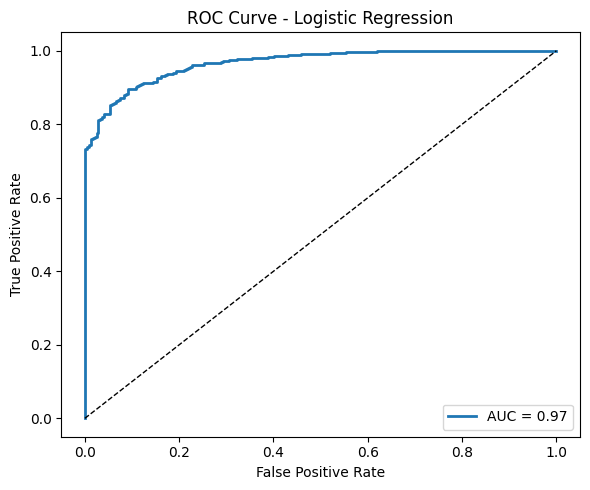


===== CLASSIFICATION REPORT (HEATMAP) =====



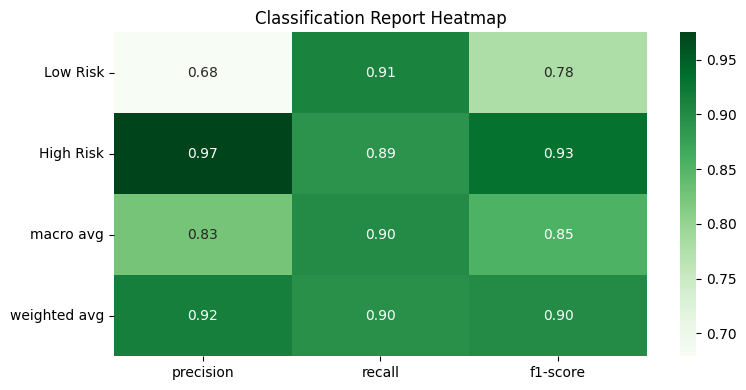

In [ ]:
# -----------------------------
# Overall Metrics
# -----------------------------
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_prob)


print("\n===== FURTHER TUNED LOGISTIC REGRESSION =====")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\n===== CLASSIFICATION REPORT (TEXT) =====\n")
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))

# -----------------------------
# 1. Confusion Matrix
# -----------------------------
print("\n===== CONFUSION MATRIX =====\n")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low Risk', 'High Risk'],
    yticklabels=['Low Risk', 'High Risk']
)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

# -----------------------------
# 2. ROC Curve
# -----------------------------
print("\n===== ROC CURVE =====\n")

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_value:.2f}", linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# -----------------------------
# 3. Classification Report Heatmap
# -----------------------------
print("\n===== CLASSIFICATION REPORT (HEATMAP) =====\n")

report = classification_report(
    y_test,
    y_pred,
    target_names=['Low Risk', 'High Risk'],
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

heatmap_df = report_df.loc[['Low Risk', 'High Risk', 'macro avg', 'weighted avg'],
                           ['precision', 'recall', 'f1-score']]

plt.figure(figsize=(8, 4))
sns.heatmap(heatmap_df, annot=True, cmap='Greens', fmt='.2f')
plt.title("Classification Report Heatmap")
plt.tight_layout()
plt.show()

**Findings**

<small>The further tuned Logistic Regression model achieved an accuracy of 89.5%, with a precision of 91.5% and an F1-score of 90.0%, indicating strong and well-balanced predictive performance. The ROC-AUC score of 0.9666 demonstrates excellent ability of the model to distinguish between low-risk and high-risk projects.</small>

<small>The classification report shows that the model performs particularly well in identifying high-risk projects, achieving very high precision (0.97) and strong recall (0.89). For low-risk projects, the model achieves a high recall (0.91), indicating that most low-risk cases are correctly identified, although precision is relatively lower (0.68), suggesting some misclassification with high-risk cases.</small>

<small>The results indicate that the model is highly effective in predicting project risk, especially in detecting high-risk scenarios, which is critical for practical decision-making.</small>